In [5]:
import json

import agama
import gc_utils
import matplotlib.pyplot as plt
import numpy as np
import utilities as ut
from scipy.ndimage import gaussian_filter1d

In [6]:
sim = "m12i"
snap = 600

sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"
fire_dir = sim_dir + sim + "/" + sim + "_res7100"

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

In [7]:
halt = gc_utils.get_halo_tree(sim, sim_dir, species=["star"])
part = gc_utils.open_snapshot(snap, fire_dir, ["star"])

Retrieving Snapshot 600..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.70s/it]


In [23]:
halo_tid = sim_data[sim]["halo"]
halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]
r_50 = halt["star.radius.50"][halo_tidx]
r_lim = 1 * r_50


msk = part["star"].prop("host.distance.principal.total") <= r_lim
vcyl = part["star"].prop("host.velocity.cylindrical")[msk]
pcyl = part["star"].prop("host.distance.cylindrical")[msk]
ages = part["star"].prop("age")[msk]

(1.0, 13.8)

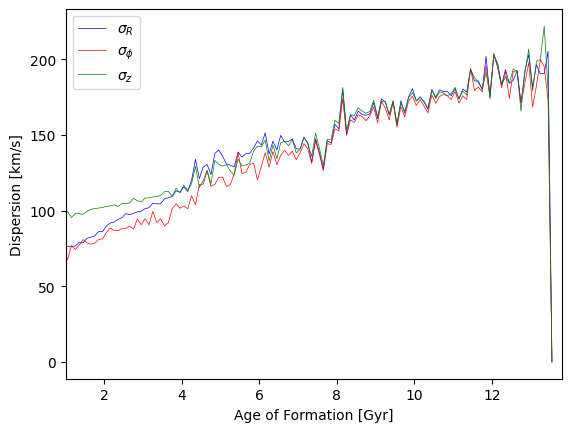

In [ ]:
vr, vp, vz = vcyl[:, 0], vcyl[:, 1], vcyl[:, 2]

bins = np.arange(0, 13.9, 0.1)

bin_idx = np.digitize(ages, bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
disp_r = np.full(len(bin_centers), np.nan)
disp_p = np.full(len(bin_centers), np.nan)
disp_z = np.full(len(bin_centers), np.nan)

for i in range(1, len(bins)):
    mask = bin_idx == i
    if np.any(mask):
        disp_r[i - 1] = np.std(vr[mask])
        disp_p[i - 1] = np.std(vp[mask])
        disp_z[i - 1] = np.std(vz[mask])

plt.plot(bin_centers, disp_r, c="b", lw=0.5, label=r"$\sigma_{R}$")
plt.plot(bin_centers, disp_p, c="r", lw=0.5, label=r"$\sigma_{\phi}$")
plt.plot(bin_centers, disp_z, c="g", lw=0.5, label=r"$\sigma_{z}$")

plt.xlabel("Age of Formation [Gyr]")
plt.ylabel("Dispersion [km/s]")
plt.legend()

plt.xlim(1, 13.8)